# Now it's time for me to perform NNs on a model dataset.

Let's use NN (micrograd) to learn boundaries from sklearn's make_moons dataset

In [1]:
# imports
import math
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
xs, ys = sklearn.datasets.make_moons()

First let's take a look at the data


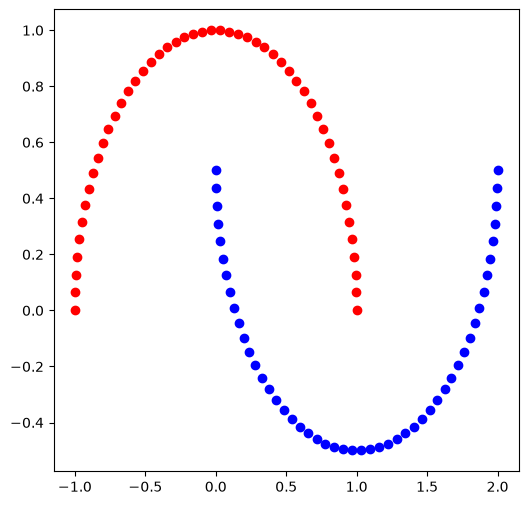

Using our intuition, we see a very clear boundary between the two moons coloured red and blue. It should look something like a sinusoid tracing the space between the red and blue arcs


In [3]:
print('First let\'s take a look at the data')
plt.figure(figsize=(6,6))
for (x, y), color_bool in zip(xs, ys):
    if color_bool == 0:
        color = 'red'
    else:
        color = 'blue'
    plt.scatter(x,y,c=color)

plt.show()

print('Using our intuition, we see a very clear boundary between the two moons coloured red and blue. It should look something like a sinusoid tracing the space between the red and blue arcs')

### So what can we do, first we need to construct the dataset.
### First thoughts:
    - input = coordinates
    - output/target = boolean, or binary indicating whether a coordinate is supposed to be red or blue.

In [4]:
print(f'We have {len(xs)} data points to learn from')
print(f'We have {len(xs[0])} inputs per data point')
print(f'We have 1 output (0/1) per data point')
print()
print(f'This tells us we would have {len(xs[0])} input nodes and 1 output node')
print(f'Hence our NN will have the general form of 2-(inner)-1, where inner depends on our settings')

We have 100 data points to learn from
We have 2 inputs per data point
We have 1 output (0/1) per data point

This tells us we would have 2 input nodes and 1 output node
Hence our NN will have the general form of 2-(inner)-1, where inner depends on our settings


# Now let's import the micrograd library from 2.1 (Neuron, Layer, MLP) and 2.2 (Value)

In [5]:
class Value:
    def __init__(self, data, label = '', children = (), operation = ''):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._prev = set(children)
        self._op = operation
        # I did not add this line, which is why my back prop did not work?
        self._backward = lambda: None

    # Had to copy this section because I forgot how to do this. And it did not occur immediately to me how important this is
    def __repr__(self):
        return f'Value(data={self.data})'

    # define useful mathematical operations
    def __add__(self, other):
        # allow non Value class inputs
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, children = (self, other), operation = '+')
        def _backward(): # in addition, children inherits parent's grad
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        # define how to act on this function
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        # allow non Value class inputs
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, children = (self, other), operation = '*')
        def _backward(): # in multiplication, children grad is defined by chain rule
            # sibling * parent grad
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        # define how to act on this function
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        # self^other
        # turns out, assigning other as a child instead of as an operator is much more complex than I initially thought
        # this is why micrograd restricted other to be an operator instead of an input
        assert isinstance(other, (int, float)), 'for simplicity, we only support power to be int/float'
        out = Value(self.data**other, children = (self, ), operation = f'**{other}')
        def _backward(): # in powers, also chain rule 
            # d(x^n)/dx = n * x^(n-1)
            self.grad += other * self.data**(other-1) * out.grad
        # define how to act on this function
        out._backward = _backward
        return out
        # # not sure how to implement float/int only for other
        # other = other if isinstance(other, Value) else Value(other)
        # out = Value(self.data**other.data, children = (self, other), operation = 'power')
        # def _backward(): # in powers, also chain rule 
        #     # d(x^n)/dx = n * x^(n-1)
        #     self.grad += other.data * self.data**(other.data-1) * out.grad 
        #     # d(x^n)/dn = x^(n)*ln(x)
        #     other.grad += other.data*np.log(self.data) * out.grad
        # # define how to act on this function
        # out._backward = _backward
        # return out

    def __neg__(self):
        # i commented these out after comparing with original. Because I don't need to do all these again,
        # __neg__ repeats what's defined in __mul__
        # out = Value(self.data * -1)
        # return out
        return self * -1 

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        return self * (other**(-1))

    # let's try exponents with no help
    def exp(self):
        out = Value(np.exp(self.data), children = (self,), operation = 'exp')
        def _backward(): # in exp, also chain rule
            # d(exp) = exp
            self.grad += out.data * out.grad
        # define how to act on this function
        out._backward = _backward
        return out

    def tanh(self):
        # # tanh = (exp(2x)-1)/(exp(2x)+1)
        # tanh = (exp(2x)-1)/(exp(2x)+1)
        x = self.data
        t = (np.exp(2*x)-1)/(np.exp(2*x)+1)
        out = Value(t, children = (self, ), operation = 'tanh')
        def _backward(): # in exp, also chain rule
            # d(tanh) = 1-tanh^2
            self.grad += (1-(out.data**2)) * out.grad
        # define how to act on this function
        out._backward = _backward
        return out
        # two_x = self*2
        # e = two_x.exp()
        # t = (e-1)/(e+1)
        # t.children = (self,); t.operation = 'tanh'
        # return t

    def backward(self):
        # cheating here, use Andrej's topological sort. Focus of this notebook is not the sort but the backprop
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                # the below loop ensures all children are added to topo before adding itself
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # reinitialize to zero in case there was carry over
        for node in topo: node.grad = 0

        self.grad = 1.0 # loss node has grad of 1
        for node in reversed(topo):
            node._backward()
    

import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        # self.w = [Value(0) for _ in range(nin)]
        # self.b = Value(0)

    def __call__(self,x):
        # w * x + b
        
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

# A layer is just a list of neurons
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)] # A layer is just a list of neurons
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs # single element list returns just the value for pretty's sake

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()] # single line of below block
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return self.w + [self.b]

# MLP: multi layer perceptron
class MLP:
    def __init__(self, nin, nouts): # nouts is a list of number of neurons in each layer, nouts = [nout1, nout2, nout3, ...]
        sz = [nin] + nouts # this gives us a full list of number of neurons in every layer, input(nin) -> layer 1 -> layer 2 -> ...
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [6]:
# remember our inputs and desired outputs are
xs, ys = sklearn.datasets.make_moons()
ys = [1 if y==1 else -1 for y in ys] # convert 0/1 boolean to -1/1 boolean. I find that using -1/1 yields a better model performance

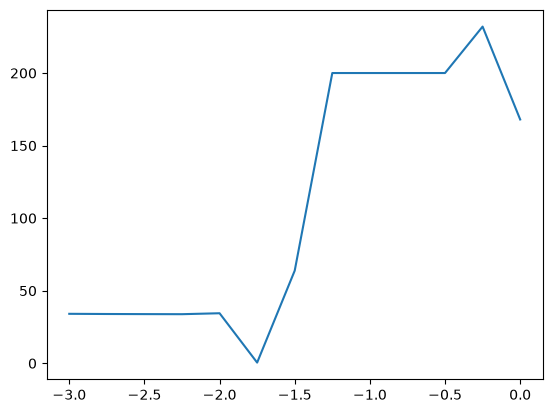

In [7]:
# learning rate optimization


# let's build a loop to minimize our loss

max_steps = 100
opt_target = 1e-3

lre = np.linspace(-3, 0, 13)
lrs = 10**lre

# # lre = np.linspace(-3, -1, max_steps)
# lrs = np.linspace(0.001, 0.1, max_steps)

step = 0
stepi = []
lri, lossi, lrei = [], [], []

ypreds = []
for i in range(len(lre)):
    random.seed(12345)
    n = MLP(2, [5, 1]) # remember, micrograd's MLP automatically generates random weights
    k = 0
    for k in range(max_steps):
        # forward pass
        ypred = [n(x) for x in xs]
        ypreds.append(ypred)

        loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]) # here we sum the squared deviation of each input to get the MSE
        loss
        # print(f'{k}: {loss.data:.6f}')

        # backward pass
        # FIRST, reset gradients
        for p in n.parameters():
            p.grad = 0
        loss.backward()

        # shift our parameters
        lr = lrs[i]
        for p in n.parameters():
            p.data += - lr * p.grad
        k+=1
    stepi.append(i)
    lri.append(lr)
    lrei.append(lre[i])
    lossi.append(loss.data)

plt.plot(lrei, lossi)
# plt.plot(lri, lossi)
plt.show()

# well we see the loss kinda falls off at 10**-2 ish so let's start there for our learning rate
# honestly, this part can be done much better but I don't have much time nor compute power. We will see down the line that 10**-2 suffices for our purposes

In [8]:
# let's try one inner layer with 5 neurons to start off

n = MLP(2, [5, 1]) # remember, micrograd's MLP automatically generates random weights

# let's build a loop to minimize our loss

max_steps = 1000
opt_target = 1e-3
k = 0

stepi, lossi = [], []

ypreds = []
while all([loss.data > opt_target, k < max_steps]):
    # forward pass
    ypred = [n(x) for x in xs]
    ypreds.append(ypred)

    loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]) # here we sum the squared deviation of each input to get the SSE
    # loss /= len(ypred)
    print(f'{k}: {loss.data:.6f}')
    stepi.append(k)
    lossi.append(loss.data)

    # backward pass
    # FIRST, reset gradients
    for p in n.parameters():
        p.grad = 0
    loss.backward()

    # shift our parameters
    lr = 10**-2 if k < 400 else (10**-2)/2 if k < 500 else 10**-3 # use lr decay learned from 3.2
    for p in n.parameters():
        p.data += - lr * p.grad
    k += 1


0: 117.048249
1: 148.783655
2: 96.569951
3: 80.713440
4: 59.039303
5: 41.146814
6: 37.849181
7: 36.307439
8: 35.517559
9: 35.894323
10: 38.933163
11: 42.751473
12: 49.749030
13: 39.154514
14: 34.403616
15: 32.397444
16: 32.326173
17: 32.266761
18: 32.990089
19: 33.511430
20: 36.145796
21: 35.806611
22: 38.041725
23: 33.722796
24: 33.102835
25: 30.960109
26: 31.498554
27: 30.918191
28: 32.671687
29: 31.520445
30: 33.283957
31: 29.933173
32: 30.020129
33: 27.033845
34: 27.790887
35: 26.146956
36: 28.571164
37: 25.750671
38: 26.608823
39: 22.113193
40: 21.782944
41: 19.653065
42: 21.487167
43: 19.482384
44: 19.576642
45: 16.198422
46: 15.119471
47: 13.641304
48: 13.612286
49: 12.332053
50: 11.264589
51: 9.907181
52: 8.680477
53: 7.691209
54: 6.615574
55: 5.813037
56: 4.986563
57: 4.412684
58: 3.918504
59: 3.582247
60: 3.324665
61: 3.134053
62: 2.979391
63: 2.847577
64: 2.729736
65: 2.621836
66: 2.521809
67: 2.428545
68: 2.341305
69: 2.259513
70: 2.182682
71: 2.110386
72: 2.042244
73: 1.97

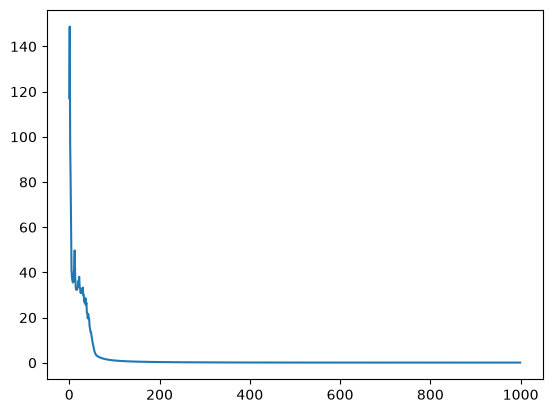

In [9]:
plt.plot(stepi, lossi)
# plt.ylim([-1, 2])
plt.show()

Let's visualize our final prediction compared to our target

If our model does well, we should see clusters of points at -1,-1 and 1,1

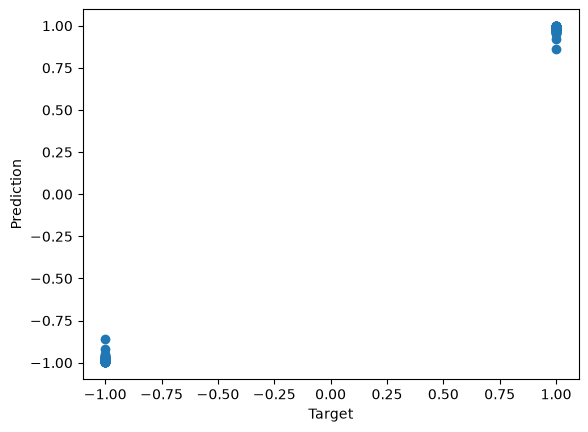

In [10]:
plt.scatter(ys, [y.data for y in ypreds[-1]])
plt.xlabel('Target')
plt.ylabel('Prediction')
plt.show()

Let's take a look at the data again and pick spaces to test our model


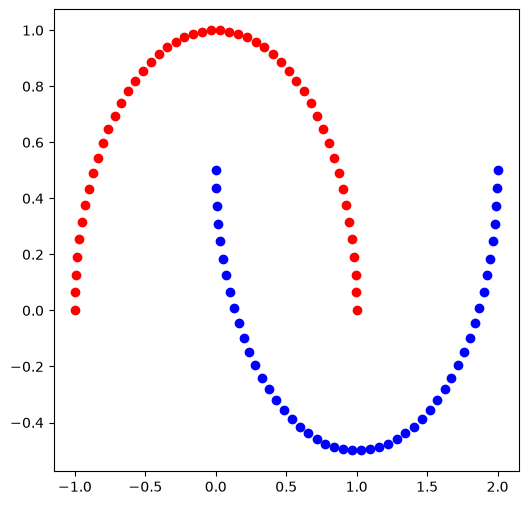

In [11]:
print('Let\'s take a look at the data again and pick spaces to test our model')
plt.figure(figsize=(6,6))
for (x, y), color_bool in zip(xs, ys):
    if color_bool == -1:
        color = 'red'
    else:
        color = 'blue'
    plt.scatter(x,y,c=color)

plt.show()

In [12]:
# try different coordinates here to see if the output value corresponds to what my intuition tells me
# reminder, -1 = red, 1 = blue
print(f'expect red, output: {n([-1,1]).data}')
print(f'expect red, output: {n([-1,-0.2]).data}')
print(f'expect red, output: {n([1.5,1]).data}')
print()
print(f'expect mix, output: {n([0.5,0.2]).data}')
print(f'expect mix, output: {n([1.5,0.2]).data}')
print(f'expect mix, output: {n([-0.5,0.2]).data}')
print()
print(f'expect blue, output: {n([2,-0.4]).data}')
print(f'expect blue, output: {n([2,0.6]).data}')
print(f'expect blue, output: {n([0,-0.4]).data}')

# Spot checks on model appears to indicate good performance

expect red, output: -0.9920866020156123
expect red, output: -0.9781863207893079
expect red, output: -0.9783188426629399

expect mix, output: -0.07141140568202535
expect mix, output: 0.10035874386292959
expect mix, output: -0.6848507589983016

expect blue, output: 0.9967473237956844
expect blue, output: 0.9263275007056321
expect blue, output: 0.9971856708651592


In [15]:
# Now let's create a mesh grid and use our model to predict the expected colour at each point

n_grid = 100
padding = 0.1

x_min, y_min = xs.min(axis=0) - padding
x_max, y_max = xs.max(axis=0) + padding

xvs, yvs = np.meshgrid(np.linspace(x_min, x_max, n_grid), np.linspace(y_min, y_max, n_grid))

z_val_grid = np.zeros_like(xvs)
# i = 0
for i, (xv, yv) in enumerate(zip(xvs, yvs)):
    # j = 0
    for j, (x, y) in enumerate(zip(xv, yv)):
        z_val = n([x,y]).data
        z_val_grid[i,j] = z_val
        # j+=1
    # i+=1

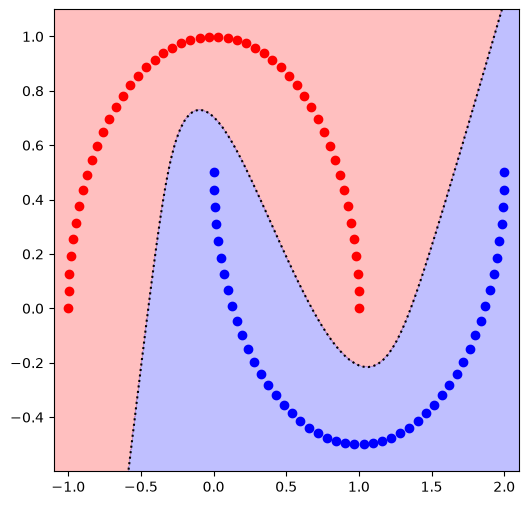

In [16]:
# plot the contour and points to see if my model properly predicted the boundary

plt.figure(figsize=(6,6))
plt.contourf(xvs, yvs, z_val_grid, levels = [-1,0,1], colors = ['red', 'blue'], alpha = 0.25)
plt.contour(xvs, yvs, z_val_grid, levels = [0], colors = ['black'], linestyles=['dotted'])

for (x, y), color_bool in zip(xs, ys):
    if color_bool == -1:
        color = 'red'
    else:
        color = 'blue'
    plt.scatter(x,y,c=color)

plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
# plt.xlim([-5, x_range[1]])
# plt.ylim([-5, y_range[1]])
plt.show()


# cs.cmap.set_over('red')
# cs.cmap.set_under('blue')
# cs.changed()

Wait this is exciting? The model appears capable of separating the two moons with a 100% success rate

The model was simple, fitting for learning boundaries on a simple dataset.

From this practice, I find that a simple 2x5x1 NN is sufficient for learning boundaries from sklearn's make_moons data
1. Changing the binary output from 0/1 to -1/1 yielded better training, likely due to the use of tanh and SSE for loss instead of cross_entropy
2. Model and data used in this practice is quite sensitive, and required a smaller learning rate.
    - learning rate optimization found that the model is quite unstable, and some artistic freedom is needed to identify an initial learning rate of 0.01 (10^-2)
3. I incorporated the above learning rate optimization and learning rate decay from notebook 3.2, which helped the sensitive model to converge